# Mapa interactivo (hover)
Visualizacion por pais con tooltip mostrando el valor.


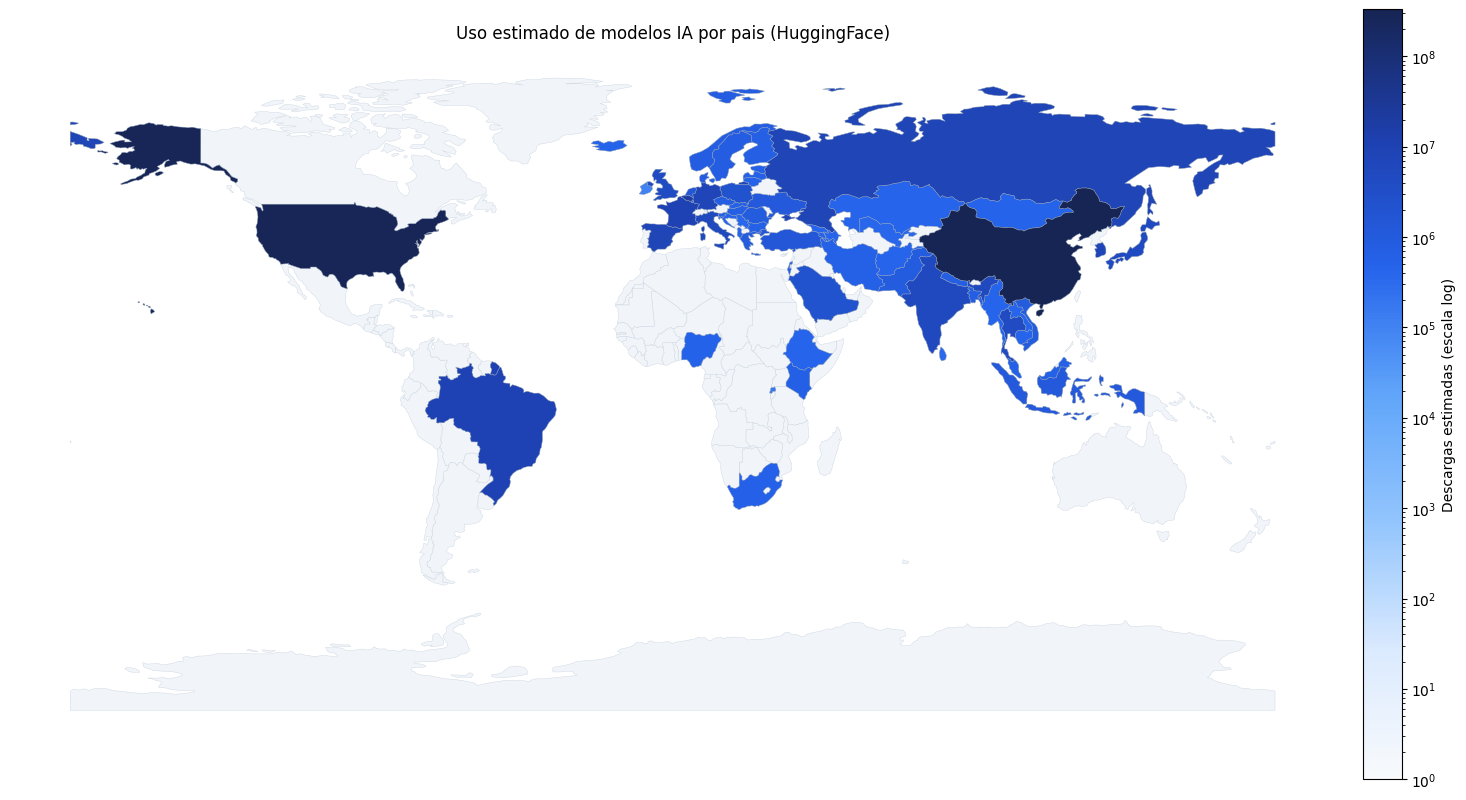

In [3]:
from pathlib import Path

import geopandas as gpd
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import pandas as pd

INPUT_CSV = Path("Data/huggingface_ia/huggingface_uso_estimado_por_pais.csv")
NE_URL = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"

df = pd.read_csv(INPUT_CSV)
df["estimated_downloads"] = pd.to_numeric(df["estimated_downloads"], errors="coerce").fillna(0.0)
df = df[df["estimated_downloads"] > 0].copy()

world = gpd.read_file(NE_URL)
world = world.rename(columns={"ISO_A3_EH": "iso3"})
fixes = {"France": "FRA", "Norway": "NOR", "Kosovo": "XKX", "Somaliland": "SOM"}
for name, code in fixes.items():
    world.loc[world["NAME"] == name, "iso3"] = code

world = world.merge(
    df[["country_iso3", "estimated_downloads"]],
    left_on="iso3",
    right_on="country_iso3",
    how="left",
)

vmin = 1.0
vmax = float(df["estimated_downloads"].max())
norm = mcolors.LogNorm(vmin=vmin, vmax=vmax)
cmap = mcolors.LinearSegmentedColormap.from_list(
    "hf_usage",
    ["#f8fafc", "#dbeafe", "#93c5fd", "#60a5fa", "#2563eb", "#1e40af", "#172554"],
    N=256,
)
cmap.set_bad(color="#e5e7eb")

fig, ax = plt.subplots(1, 1, figsize=(18, 10))
world.plot(ax=ax, color="#f1f5f9", edgecolor="#cbd5e1", linewidth=0.3)

has_data = world["estimated_downloads"].notna()
world[has_data].plot(
    ax=ax,
    column="estimated_downloads",
    cmap=cmap,
    norm=norm,
    edgecolor="#94a3b8",
    linewidth=0.3,
    legend=False,
)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label("Descargas estimadas (escala log)")

ax.set_title("Uso estimado de modelos IA por pais (HuggingFace)")
ax.axis("off")
plt.show()